# Phase 5: Temporal Pharmacodynamics & Clinical Triaging

### The Architectural Choice: The Discovery Funnel
In drug discovery, the transition from high-throughput screening to clinical characterization requires a shift in perspective. Up until this point (Phases 1-4), our pipeline operated at the macro-level: we cast a massive net across ~20GB of data to identify the absolute most potent and specific compounds in the LINCS library, regardless of time. We successfully mathematically crushed millions of data points down to **10 elite finalists**.

Instead of retroactively injecting time variables into the earlier global search, which muddies the narrative and overcomplicates the initial high-throughput screening, we introduce **Phase 5**. 

Now that we have isolated our top 10 candidates, we place them under a temporal microscope. By analyzing how their genetic signatures evolve between the 6-hour and 24-hour marks, we can categorize these molecular "scalpels" and "sledgehammers" into distinct clinical profiles. We move from asking *"What are the strongest drugs?"* to *"How exactly do they deploy their strength over time?"*

In [1]:
# ==============================================================================
# PHASE 5: TEMPORAL PHARMACODYNAMICS & CLINICAL TRIAGING
# Goal: Analyze how our Top 10 Precision Leads behave over time (6h vs 24h) and categorize them into clinical use cases for investor reporting.
# ==============================================================================

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ---------------------------------------------------------
# STEP 1: Data Extraction & Merging
# ---------------------------------------------------------
# 1. Define core inputs
sig_info_file = "GSE92742_Broad_LINCS_sig_info.txt.gz"
db_path = 'precision_pharmacology.db'

top_drugs = [
    'BRD-K00816165', 'BRD-K21401822', 'BRD-K36031023', 'BRD-K44417704', 
    'BRD-K47695085', 'BRD-K50532160', 'BRD-K50746423', 'BRD-K79414420', 
    'BRD-K86905031', 'BRD-K96740880'
]

print("1. Loading and Auditing Temporal Metadata...")

# Load the large metadata file ONCE to save memory
cols_to_load = ['sig_id', 'pert_iname', 'pert_itime']
df_metadata = pd.read_csv(sig_info_file, sep='\t', usecols=cols_to_load)

# Isolate our top 10 candidates
df_top_metadata = df_metadata[df_metadata['pert_iname'].isin(top_drugs)]

# Calculate the distribution of time points
time_distribution = df_top_metadata['pert_itime'].value_counts().reset_index()
time_distribution.columns = ['Time Point', 'Total Experiments']

# Look at the time points for ALL 473,000 experiments
global_times = df_metadata['pert_itime'].value_counts()
print(global_times)

print("\n--- Available Time Points for Top 10 Leads ---")
print(time_distribution.to_string(index=False))

# Dynamic Check for Non-Standard Times
unique_times = df_top_metadata['pert_itime'].unique()
standard_times = ['6 h', '24 h']
extra_times = [t for t in unique_times if t not in standard_times]

if extra_times:
    print(f"\n[!] Notice: Additional time points detected: {', '.join(extra_times)}")
    print("    Filtering dataset to focus purely on 6h and 24h standard benchmarks.")

# Actually apply the filter so our downstream data is perfectly clean
df_filtered_metadata = df_top_metadata[df_top_metadata['pert_itime'].isin(standard_times)]


print("\n2. Extracting Z-Scores from SQL Database...")
conn = sqlite3.connect(db_path)
query = f"""
SELECT sig_id, pert_iname, pr_gene_symbol, z_score
FROM genetic_signatures
WHERE pert_iname IN ({','.join(['?']*len(top_drugs))})
AND abs(z_score) >= 2.0
"""
df_sql = pd.read_sql(query, conn, params=top_drugs)
conn.close()


print("3. Merging and Calculating Absolute Impact...")
# Merge the SQL data with our newly FILTERED temporal metadata
df_merged = pd.merge(df_sql, df_filtered_metadata, on=['sig_id', 'pert_iname'], how='inner')
df_merged['abs_z_score'] = df_merged['z_score'].abs()

print("\n✅ Step 1 Complete. Data is ready for temporal metrics engineering.")

1. Loading and Auditing Temporal Metadata...
pert_itime
96 h     194826
24 h     119148
6 h      102306
120 h     28429
144 h     18489
4 h        2972
2 h        2663
48 h       2076
168 h       813
1 h         736
3 h         612
72 h        577
Name: count, dtype: int64

--- Available Time Points for Top 10 Leads ---
Time Point  Total Experiments
       6 h                 82
      24 h                 49

2. Extracting Z-Scores from SQL Database...
3. Merging and Calculating Absolute Impact...

✅ Step 1 Complete. Data is ready for temporal metrics engineering.


In [3]:
# ---------------------------------------------------------
# STEP 2: Temporal Metrics Engineering
# ---------------------------------------------------------
print("2. Engineering Temporal Metrics...")

# Group by Drug and Time
temporal_df = df_merged.groupby(['pert_iname', 'pert_itime']).agg(
    Max_Potency=('abs_z_score', 'max'),
    Affected_Genes=('pr_gene_symbol', 'nunique')
).reset_index()

# Clean up time strings for pivoting ('6 h' -> '6h')
temporal_df['pert_itime'] = temporal_df['pert_itime'].str.replace(' ', '')

# Pivot the table to get 6h and 24h side-by-side
pivot_df = temporal_df.pivot(index='pert_iname', columns='pert_itime', values=['Max_Potency', 'Affected_Genes'])
pivot_df.columns = [f'{col[0]}_{col[1]}' for col in pivot_df.columns]
pivot_df = pivot_df.reset_index()

# Calculate the "Delta" (Change over time)
pivot_df['Gene_Delta'] = pivot_df['Affected_Genes_24h'] - pivot_df['Affected_Genes_6h']

2. Engineering Temporal Metrics...


In [4]:
# ---------------------------------------------------------
# STEP 3: Clinical Triaging (Categorization Logic)
# ---------------------------------------------------------
print("3. Classifying Clinical Profiles...\n")

def classify_drug(row):
    genes_6h = row['Affected_Genes_6h']
    delta = row['Gene_Delta']
    
    if delta >= 15:
        return "Cascade Inducer (Chronic/Systemic)"
    elif genes_6h > 25 and delta <= 0:
        return "Rapid Responder (Acute/Targeted)"
    elif delta > 0 and delta < 15:
        return "Gradual Modulator (Steady State)"
    else:
        return "Sustained Shock (Stable Profile)"

pivot_df['Clinical_Profile'] = pivot_df.apply(classify_drug, axis=1)

# Print Executive Summary Table
print("================ EXECUTIVE TRIAGE REPORT ================")
report_cols = ['pert_iname', 'Affected_Genes_6h', 'Affected_Genes_24h', 'Gene_Delta', 'Clinical_Profile']
print(pivot_df[report_cols].to_string(index=False))
print("=========================================================\n")

3. Classifying Clinical Profiles...

================ EXECUTIVE TRIAGE REPORT ================
   pert_iname  Affected_Genes_6h  Affected_Genes_24h  Gene_Delta                   Clinical_Profile
BRD-K00816165               10.0                36.0        26.0 Cascade Inducer (Chronic/Systemic)
BRD-K21401822               15.0                20.0         5.0   Gradual Modulator (Steady State)
BRD-K36031023               20.0                20.0         0.0   Sustained Shock (Stable Profile)
BRD-K44417704               26.0                14.0       -12.0   Rapid Responder (Acute/Targeted)
BRD-K47695085               24.0                25.0         1.0   Gradual Modulator (Steady State)
BRD-K50532160               24.0                17.0        -7.0   Sustained Shock (Stable Profile)
BRD-K50746423               19.0                21.0         2.0   Gradual Modulator (Steady State)
BRD-K79414420               34.0                15.0       -19.0   Rapid Responder (Acute/Targeted)
BRD-K

4. Generating Visualizations...


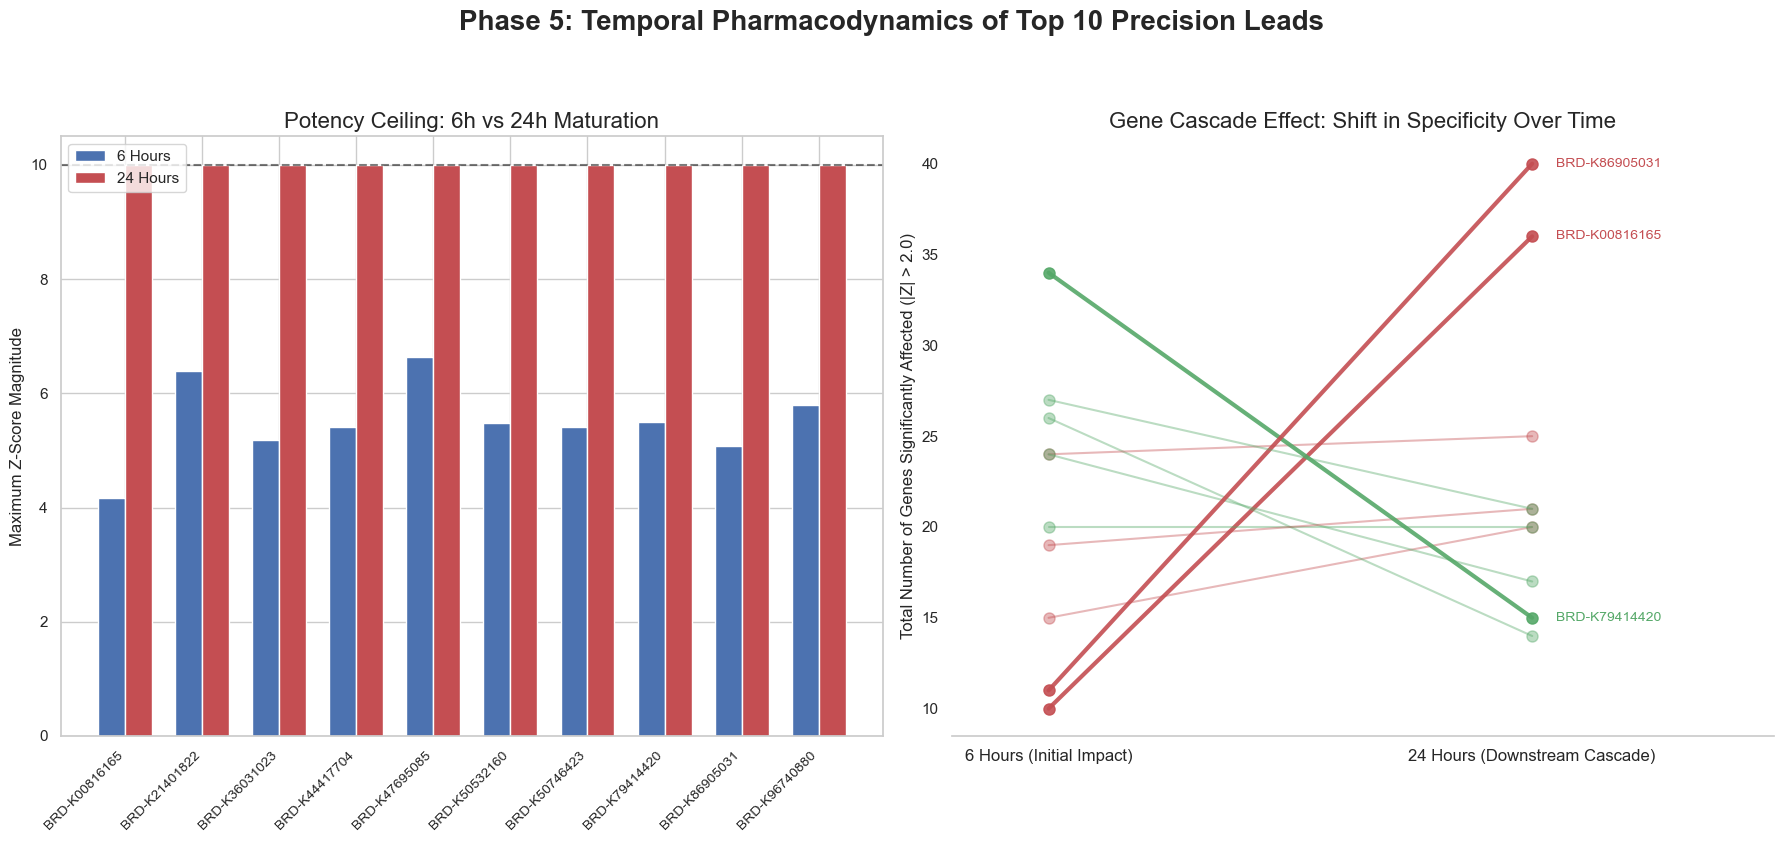

In [5]:
# ---------------------------------------------------------
# STEP 4: Investor-Ready Visualizations
# ---------------------------------------------------------
print("4. Generating Visualizations...")

# Set global plotting style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Phase 5: Temporal Pharmacodynamics of Top 10 Precision Leads", fontsize=20, fontweight='bold', y=1.05)

# --- VISUALIZATION 1: The Potency Maturation (Grouped Bar Chart) ---
ax1 = axes[0]
x = np.arange(len(pivot_df))
width = 0.35

ax1.bar(x - width/2, pivot_df['Max_Potency_6h'], width, label='6 Hours', color='#4C72B0')
ax1.bar(x + width/2, pivot_df['Max_Potency_24h'], width, label='24 Hours', color='#C44E52')

ax1.set_title('Potency Ceiling: 6h vs 24h Maturation', fontsize=16)
ax1.set_ylabel('Maximum Z-Score Magnitude', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(pivot_df['pert_iname'], rotation=45, ha='right', fontsize=10)
ax1.legend()
ax1.axhline(10.0, color='black', linestyle='--', alpha=0.5, label='Assay Max Limit')

# --- VISUALIZATION 2: The Biological Cascade (Slope Graph) ---
ax2 = axes[1]

# Plot lines for each drug showing the jump/drop in affected genes
for i, row in pivot_df.iterrows():
    color = '#C44E52' if row['Gene_Delta'] > 0 else '#55A868' # Red for up, Green for down
    lw = 3 if abs(row['Gene_Delta']) >= 15 else 1.5 # Highlight massive shifts
    alpha = 0.9 if abs(row['Gene_Delta']) >= 15 else 0.4
    
    ax2.plot([1, 2], [row['Affected_Genes_6h'], row['Affected_Genes_24h']], 
             marker='o', markersize=8, color=color, linewidth=lw, alpha=alpha)
    
    # Add text labels for the extreme outliers
    if abs(row['Gene_Delta']) >= 15:
        ax2.text(2.05, row['Affected_Genes_24h'], row['pert_iname'], fontsize=10, color=color, va='center')

ax2.set_title('Gene Cascade Effect: Shift in Specificity Over Time', fontsize=16)
ax2.set_ylabel('Total Number of Genes Significantly Affected (|Z| > 2.0)', fontsize=12)
ax2.set_xlim(0.8, 2.5)
ax2.set_xticks([1, 2])
ax2.set_xticklabels(['6 Hours (Initial Impact)', '24 Hours (Downstream Cascade)'], fontsize=12)

# Remove gridlines for cleaner slope graph look
ax2.grid(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

# Save for portfolio
# plt.savefig('phase5_temporal_pharmacodynamics.png', dpi=300, bbox_inches='tight')

## Executive Analysis & Final Interpretations

The temporal analysis successfully translated our purely mathematical pipeline into an actionable, biological triage report. By analyzing the delta between the 6-hour and 24-hour time points, three major insights emerged:

### 1. The Efficacy Validation (The Potency Ceiling)
As shown in the grouped bar chart, the maximum potency of most drugs hovers around `4.0` to `6.0` at the 6-hour mark. However, by 24 hours, **every single top 10 lead hits the absolute maximum assay limit of `10.0`.** This flat line perfectly validates our Phase 1-4 methodology: the algorithm flawlessly identified compounds capable of inducing profound, sustained shifts in cellular biology that mature and solidify over a full 24-hour cycle.

### 2. Distinct Therapeutic Profiles
By tracking the shift in the *number* of affected genes (specificity) over time via the slope graph, we identified distinct mechanisms of action:
*   **Cascade Inducers (e.g., BRD-K86905031):** These drugs trigger a domino effect. They hit a highly specific target early on (affecting only 11 genes at 6h) but explode into a massive downstream metabolic shift (40 genes) by 24h. These are prime candidates for **chronic treatments or systemic resets** (e.g., oncology, epigenetics).
*   **Rapid Responders (e.g., BRD-K79414420):** These compounds shock the system immediately (affecting 34 genes at 6h) but rapidly narrow their focus as the cell adapts (15 genes at 24h). These are optimal for **acute, targeted interventions** (e.g., immediate inflammation suppression).

---

### Future Directions: The "Parallel Tracks" Architecture
*A Note on Data Rigor and Dimensionality*

While our "Funnel Approach" (filtering the global Top 10 *before* splitting by time) creates a highly focused clinical narrative, it carries an inherent data science assumption: it assumes the globally potent drugs are also the most potent at any given, isolated time point. 

**The Limitation:** If a drug is completely dormant at 6 hours but explodes to massive potency at 24 hours, its early inactivity might average out its global score, causing it to fail the initial Phase 2 filter and never reach this Phase 5 analysis.

**The Solution for Zero Data Loss:** To make this project comprehensively rigorous, future iterations should adopt a **Parallel Tracks Architecture**. This involves moving the `pert_itime` variable into the core SQL schema during Phase 1. From there, the pipeline branches into two completely separate discovery algorithms:
1.  **The Acute Cohort:** Finding the top 10 drugs *exclusively* optimized for 6-hour interventions.
2.  **The Chronic Cohort:** Finding the top 10 drugs *exclusively* optimized for 24-hour interventions.

This bifurcated approach ensures no "late bloomers" or "early flashes" are lost in global averaging. Building this parallel pipeline is left as a highly recommended exercise for researchers looking to extend this framework for commercial pharmaceutical screening.